# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [ ]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [ ]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [ ]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5], dtype=int64)

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

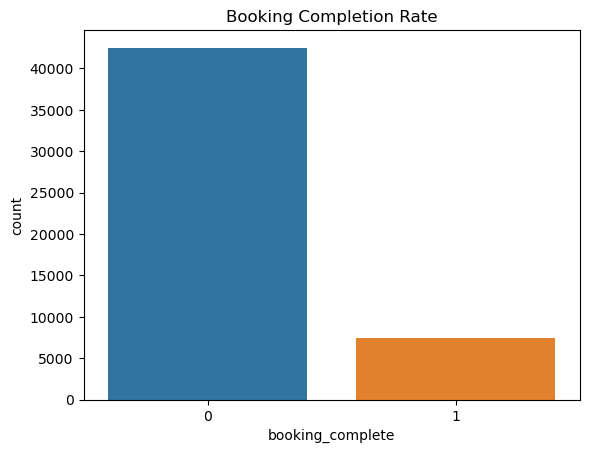

In [ ]:
# Target balance
sns.countplot(data=df, x='booking_complete')
plt.title('Booking Completion Rate')
plt.show()

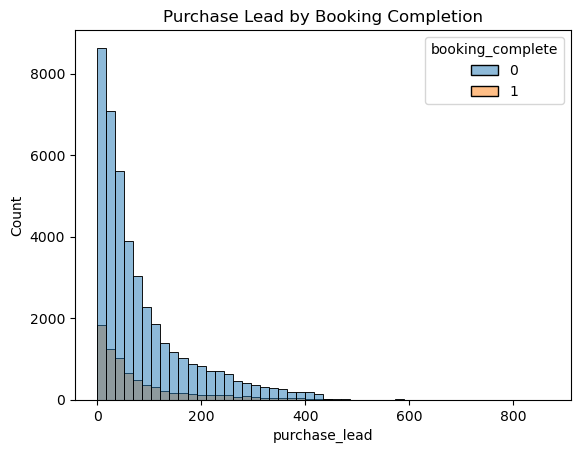

In [ ]:
# Purchase lead vs. booking completion
sns.histplot(data=df, x='purchase_lead', hue='booking_complete', bins=50)
plt.title('Purchase Lead by Booking Completion')
plt.show()

#### Data Cleaning

In [ ]:
df["trip_type"].unique()

array(['RoundTrip', 'CircleTrip', 'OneWay'], dtype=object)

In [ ]:
map_it = {
    "RoundTrip": 1,
    "CircleTrip": 2,
    "OneWay": 3,
}

df["trip_type"] = df["trip_type"].map(map_it)
df["trip_type"].unique()

array([1, 2, 3], dtype=int64)

In [ ]:
df = df.dropna(subset=['sales_channel'])

In [ ]:
df['sales_channel'].unique()

array(['Internet', 'Mobile'], dtype=object)

In [ ]:
map_two = {
    'Internet': 1,
    'Mobile': 2,
}

df['sales_channel'] = df["sales_channel"].map(map_two)
df['sales_channel'].unique()

array([1, 2], dtype=int64)

In [ ]:
# Replace route with its frequency
route_freq = df['route'].value_counts().to_dict()
df['route_freq'] = df['route'].map(route_freq)

# Replace booking_origin with its frequency
origin_freq = df['booking_origin'].value_counts().to_dict()
df['origin_freq'] = df['booking_origin'].map(origin_freq)

# Drop the original columns
df = df.drop(['route', 'booking_origin'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # for reproducibility
    stratify=y  # keeps the same class balance in both sets
)

### Train/Test Split

In [ ]:
# Check the shapes
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# Check the class balance
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True)}")

Train shape: (40000, 13)
Test shape: (10000, 13)
Train class balance:
booking_complete
0    0.85045
1    0.14955
Name: proportion, dtype: float64
Test class balance:
booking_complete
0    0.8504
1    0.1496
Name: proportion, dtype: float64


### Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Train it
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

#### Evaluate

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Predictions
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8538
ROC-AUC: 0.7680

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.57      0.09      0.15      1496

    accuracy                           0.85     10000
   macro avg       0.72      0.54      0.54     10000
weighted avg       0.82      0.85      0.81     10000



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

model = xgb.XGBClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # for ROC‑AUC

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC‑AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8476
Precision: 0.4617
Recall: 0.1130
F1 Score: 0.1815
ROC‑AUC: 0.7862

Confusion Matrix:
[[8307  197]
 [1327  169]]


- **Accuracy = 84.8%:** Deceptive. The model is right most of the time by always saying "no."
- **Recall = 11.3%:** It catches only 1 in 9 actual bookings.
- **Precision = 46.2%:** When it does say "yes," it's wrong more than half the time.
- **ROC-AUC = 0.786:** Better than random (0.5), but not strong. There's some signal, but it's weak.
- **Confusion Matrix:** 169 true positives, 1327 false negatives. It missed 1,327 bookings.

In [ ]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

                  feature  importance
12            origin_freq    0.245821
1           sales_channel    0.101300
7     wants_extra_baggage    0.097069
10        flight_duration    0.072845
8    wants_preferred_seat    0.070748
2               trip_type    0.067595
11             route_freq    0.067140
4          length_of_stay    0.054291
9   wants_in_flight_meals    0.053494
3           purchase_lead    0.045875
5             flight_hour    0.041883
0          num_passengers    0.041349
6              flight_day    0.040590


*The most important features were origin_freq (customer country frequency) and sales_channel. Passengers from certain countries and those booking via mobile were more likely to complete. Add-ons like extra baggage and preferred seats also showed some predictive power, suggesting that customers who invest in extras are more committed. However, overall recall remained low (11%), indicating that the available features do not strongly predict booking completion. Future work should incorporate customer loyalty data, price sensitivity, or competitor pricing.*
